In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read raw dataset 
df = pd.read_csv(r"C:\Users\Manoj\OneDrive\Desktop\financial_fraud_detection_dataset.csv")

In [3]:
# Quickly inspect first rows 
df.head(5)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [4]:
# ensure proper datatype for analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

In [5]:
# Check duplicates and remove duplicates 
Duplicate_count = df["transaction_id"].duplicated().sum()
print(f"Duplicate_count : {Duplicate_count}")

Duplicate_count : 0


In [6]:
# Check missing values and categorcal fill
df.isna().sum()

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

In [7]:
# drop critical columns 
df.drop(["fraud_type","time_since_last_transaction"],axis=1,inplace=True)

In [8]:
# Check and correct data types 
df.dtypes
df["timestamp"] = pd.to_datetime(df["timestamp"],errors="coerce").dt.floor("s")
df.dropna(subset=["timestamp"],inplace=True)
df["is_fraud"] = df["is_fraud"].astype(int)
df.head(5)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22 09:22:43,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,0,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04 01:58:02,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,0,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12 11:39:33,ACC733052,ACC377370,2773.86,deposit,other,London,pos,0,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10 06:04:43,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,0,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24 08:09:02,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,0,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [9]:
# Understand numeric distribution
df.describe()

,timestamp,amount,is_fraud,spending_deviation_score,velocity_score,geo_anomaly_score
count,4999997,4.999997e+06,4.999997e+06,4.999997e+06,4.999997e+06,4.999997e+06
mean,2023-07-03 00:10:09.918579200,3.589344e+02,3.591062e-02,-3.882662e-04,1.050132e+01,5.000292e-01
min,2023-01-01 00:09:26,1.000000e-02,0.000000e+00,-5.260000e+00,1.000000e+00,0.000000e+00
25%,2023-04-02 17:32:38,2.657000e+01,0.000000e+00,-6.800000e-01,5.000000e+00,2.500000e-01
50%,2023-07-03 01:27:16,1.386700e+02,0.000000e+00,0.000000e+00,1.100000e+01,5.000000e-01
75%,2023-10-02 05:43:06,5.038900e+02,0.000000e+00,6.700000e-01,1.600000e+01,7.500000e-01
max,2024-01-01 22:58:30,3.520570e+03,1.000000e+00,5.020000e+00,2.000000e+01,1.000000e+00
std,NaN,4.699334e+02,1.860673e-01,1.000807e+00,5.766844e+00,2.886350e-01


In [10]:
# Fraud KPIs 
Total_tnx = df.shape[0]
Fraud_count = df["is_fraud"].sum()
Fraud_rate = df["is_fraud"].mean() * 100
Fraud_amount = df.loc[df["is_fraud"]==1,"amount"].sum()
Fraud_avg_amount = df.loc[df["is_fraud"] == 1,"amount"].mean()
print(f"Total transaction : {Total_tnx}")
print(f"Total fraud tnx : {Fraud_count}")
print(f"Fraud rate(%) : {Fraud_rate.round(2)}")
print(f"Total fraud amount : {Fraud_amount.round(2)}")
print(f"Average fraud amount : {Fraud_avg_amount.round(2)}")

Total transaction : 4999997
Total fraud tnx : 179553
Fraud rate(%) : 3.59
Total fraud amount : 64374813.8
Average fraud amount : 358.53


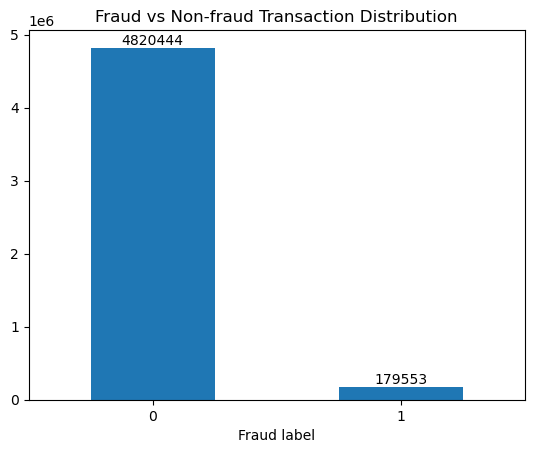

In [11]:
# Fraud vs non-fraud distribution 
fraud_counts = df["is_fraud"].value_counts().plot(kind="bar",title="Fraud vs Non-fraud Transaction Distribution")
fraud_counts.bar_label(fraud_counts.containers[0],fmt="%d")
plt.xlabel("Fraud label")
plt.xticks(rotation=0)
plt.show()

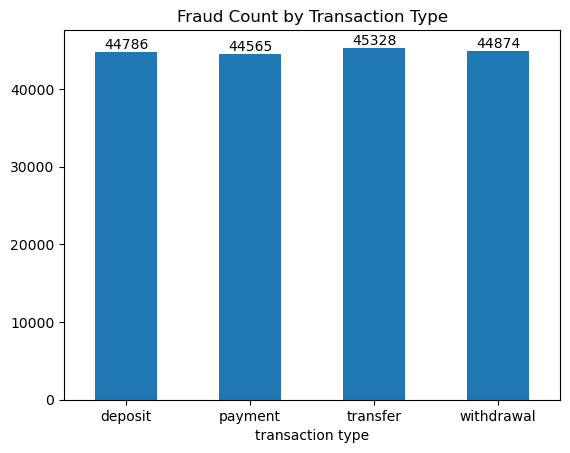

In [12]:
# Fraud count by transaction type
fraud_by_transaction = df.groupby('transaction_type')["is_fraud"].sum().plot(kind="bar",title="Fraud Count by Transaction Type")
plt.xlabel("transaction type")
fraud_by_transaction.bar_label(fraud_by_transaction.containers[0])
plt.xticks(rotation=0)
plt.show()

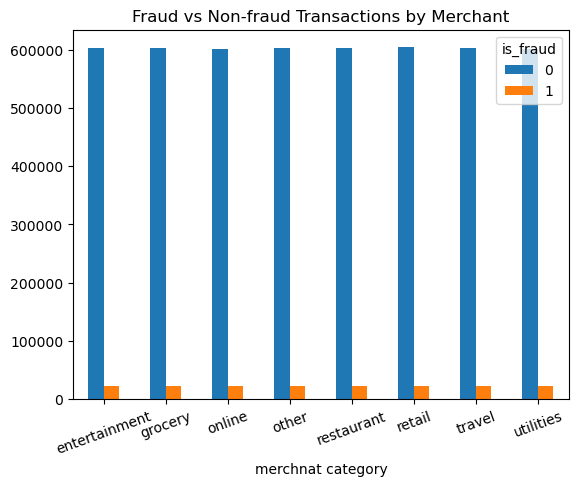

In [13]:
# Fraud counts by merchant category
fraud_by_merchant = df.groupby(["merchant_category","is_fraud"]).size().unstack(fill_value=0).plot(kind="bar")
plt.title("Fraud vs Non-fraud Transactions by Merchant")
plt.xlabel("merchnat category")
plt.xticks(rotation=20)
plt.show()

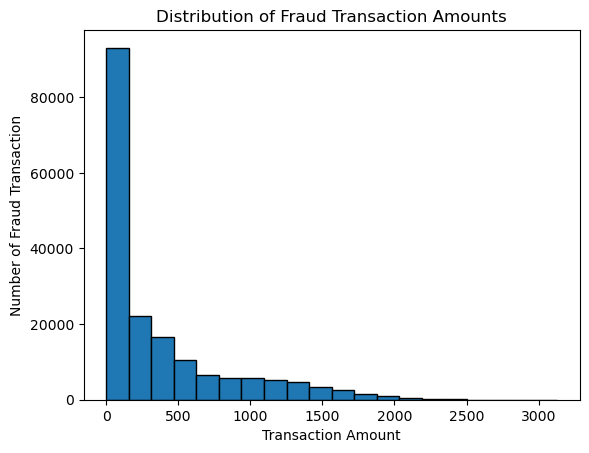

In [14]:
# Fraud amount distributin 
fraud_df = df[df["is_fraud"] == 1]
plt.hist(fraud_df["amount"],bins=20,edgecolor='black')
plt.title("Distribution of Fraud Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Fraud Transaction")
plt.show()

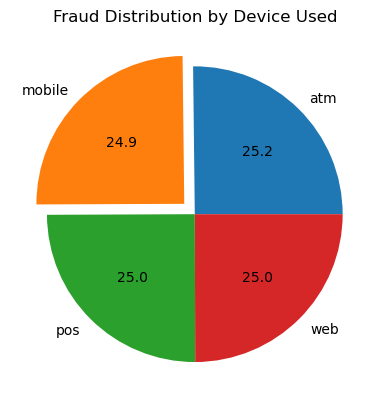

In [15]:
# Fraud device Distribution 
Device_fraud_count = fraud_df.groupby("device_used").size()
ax = Device_fraud_count.plot(kind="pie",autopct="%1.1f",explode=[0,0.1,0,0],title="Fraud Distribution by Device Used")

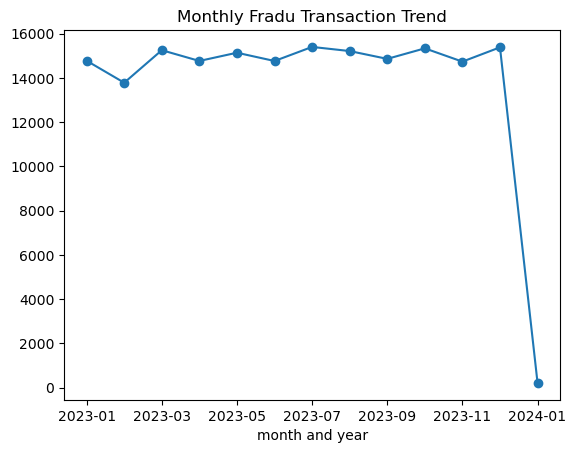

In [16]:
# Monthly fraud transaction trend
df["month_year"] = pd.to_datetime(df["timestamp"]).dt.strftime("%Y-%m")
monthly_fraud = df.groupby("month_year")["is_fraud"].sum()
ax = monthly_fraud.plot(kind="line",marker="o",title="Monthly Fradu Transaction Trend")
plt.xlabel("month and year")
plt.show()

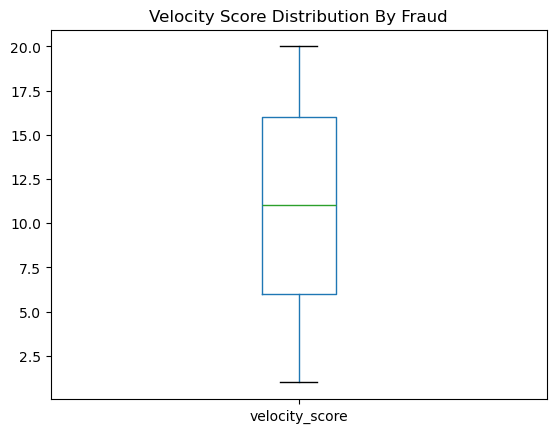

In [17]:
# Veloctity score distribution by fraud 
fraud_df.boxplot(column="velocity_score")
plt.title("Velocity Score Distribution By Fraud")
plt.suptitle("")
plt.grid()

In [18]:
# Create risk level column based on velocity score
df["risk_level"] = pd.qcut(df["velocity_score"],3,labels=["Low risk","Medium risk","High risk"])

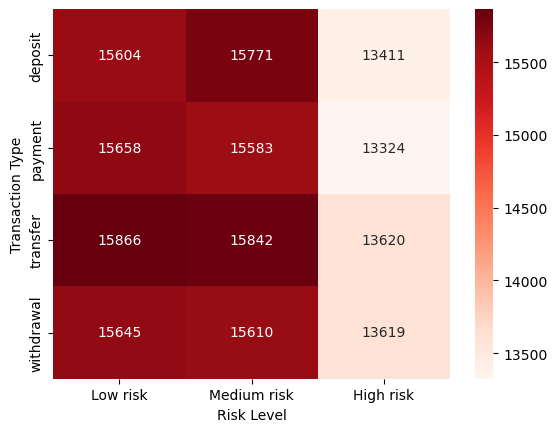

In [19]:
# Fraud risk and transaction type heat map
fraud_pivot = df[df["is_fraud"] == 1].pivot_table(index="transaction_type",columns="risk_level",values="transaction_id",aggfunc="count",observed=True)
sns.heatmap(fraud_pivot,annot=True,fmt="d",cmap="Reds")
plt.xlabel("Risk Level")
plt.ylabel("Transaction Type")
plt.show()

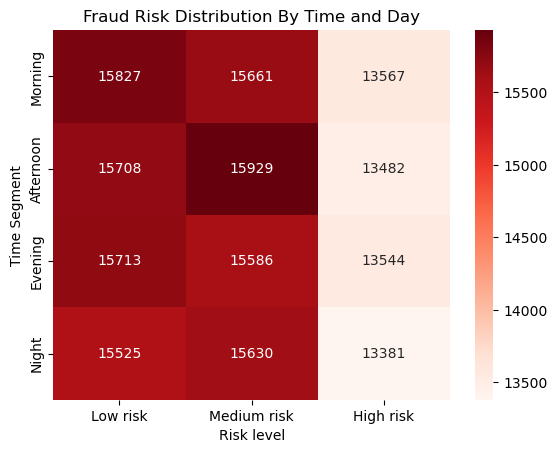

In [20]:
# Fraud risk distribution by hour 
df["hour"] = pd.to_datetime(df["timestamp"]).dt.hour
df["time_segment"] = pd.qcut(df["hour"],4,labels=["Morning","Afternoon","Evening","Night"])
hour_risk_pivot = df[df["is_fraud"] == 1].pivot_table(index="time_segment",columns="risk_level",aggfunc="size",observed=True)
sns.heatmap(hour_risk_pivot,annot=True,fmt="d",cmap="Reds")
plt.title("Fraud Risk Distribution By Time and Day")
plt.xlabel("Risk level")
plt.ylabel("Time Segment")
plt.show()

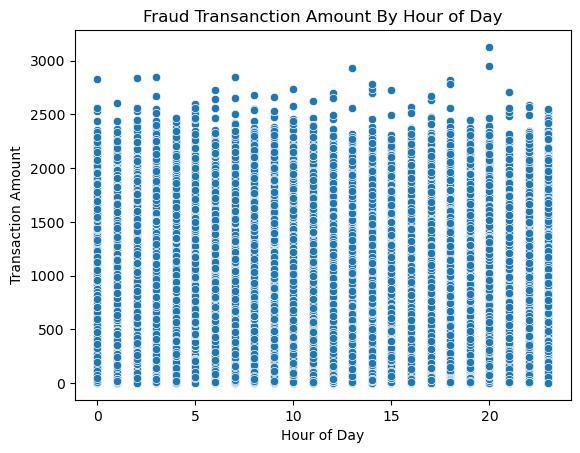

In [21]:
# Fraud amount distribution by hour
ax = sns.scatterplot(data=df[df["is_fraud"] == 1],x="hour",y="amount")
plt.title("Fraud Transanction Amount By Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Amount")
plt.show()

In [23]:
# Import timedelta and sort values 
from datetime import timedelta
df.sort_values(by="timestamp",ascending=True).head(5)

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,month_year,risk_level,hour,time_segment
4883224,T4983224,2023-01-01 00:09:26,ACC259476,ACC189392,12.25,transfer,grocery,Dubai,atm,0,-0.32,2,0.96,UPI,89.75.248.198,D9764559,2023-01,Low risk,0,Morning
14745,T114745,2023-01-01 00:11:36,ACC478421,ACC105006,1347.27,deposit,travel,Sydney,mobile,0,-0.68,5,0.67,UPI,108.75.191.104,D2292342,2023-01,Low risk,0,Morning
2901064,T3001064,2023-01-01 00:12:48,ACC830612,ACC593266,20.79,payment,travel,Tokyo,web,0,0.14,8,0.42,wire_transfer,215.139.243.78,D9777735,2023-01,Medium risk,0,Morning
548800,T648800,2023-01-01 00:21:19,ACC647991,ACC371308,740.73,deposit,utilities,Berlin,mobile,0,-2.09,20,0.86,UPI,126.146.190.250,D4372592,2023-01,High risk,0,Morning
3417687,T3517687,2023-01-01 00:23:15,ACC984405,ACC167110,228.67,deposit,grocery,Dubai,mobile,0,0.16,18,0.82,UPI,131.27.227.151,D3545707,2023-01,High risk,0,Morning


In [24]:
# Caculate last 15 mins fraud counts 
max_time = df["timestamp"].max()
last_15_mins = df[df["timestamp"] >= max_time - timedelta(minutes=15)]
last_15_mins["is_fraud"].value_counts().reindex([0,1],fill_value=0)

is_fraud
0    11
1     0
Name: count, dtype: int64

In [25]:
# Calculate last one hour fraud counts 
last_1_hour = df[df["timestamp"] >= max_time - timedelta(hours=1)]
last_1_hour["is_fraud"].value_counts().reindex([0,1],fill_value=0)

is_fraud
0    25
1     0
Name: count, dtype: int64

In [26]:
# Calulate last one day fraud counts 
last_1_day =df[df["timestamp"] >= max_time - timedelta(days=1)]
last_1_day["is_fraud"].value_counts()

is_fraud
0    6736
1     237
Name: count, dtype: int64

In [27]:
# Calculate last month fraud counts
last_month = df[df["timestamp"] >= max_time - pd.DateOffset(months=1)]
last_month["is_fraud"].value_counts()

is_fraud
0    402586
1     15096
Name: count, dtype: int64

In [35]:
df_50k = df.head(34000)

In [37]:
df_50k.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34000 entries, 2023-01-01 00:09:26 to 2023-01-03 22:59:48
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   transaction_id            34000 non-null  object  
 1   sender_account            34000 non-null  object  
 2   receiver_account          34000 non-null  object  
 3   amount                    34000 non-null  float64 
 4   transaction_type          34000 non-null  object  
 5   merchant_category         34000 non-null  object  
 6   location                  34000 non-null  object  
 7   device_used               34000 non-null  object  
 8   is_fraud                  34000 non-null  int64   
 9   spending_deviation_score  34000 non-null  float64 
 10  velocity_score            34000 non-null  int64   
 11  geo_anomaly_score         34000 non-null  float64 
 12  payment_channel           34000 non-null  object  
 13  ip_address 

In [38]:
df_50k.to_csv("financial_fraud_sample_data.csv",index=False)

In [77]:
import os 
os.getcwd()

'C:\\Users\\Manoj'

In [95]:
df.head(5)

,timestamp,transaction_id,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash,month_year,risk_level
0,2023-01-01 00:09:26,T4983224,ACC259476,ACC189392,12.25,transfer,grocery,Dubai,atm,0,-0.32,2,0.96,UPI,89.75.248.198,D9764559,2023-01,Low risk
1,2023-01-01 00:11:36,T114745,ACC478421,ACC105006,1347.27,deposit,travel,Sydney,mobile,0,-0.68,5,0.67,UPI,108.75.191.104,D2292342,2023-01,Low risk
2,2023-01-01 00:12:48,T3001064,ACC830612,ACC593266,20.79,payment,travel,Tokyo,web,0,0.14,8,0.42,wire_transfer,215.139.243.78,D9777735,2023-01,Medium risk
3,2023-01-01 00:21:19,T648800,ACC647991,ACC371308,740.73,deposit,utilities,Berlin,mobile,0,-2.09,20,0.86,UPI,126.146.190.250,D4372592,2023-01,High risk
4,2023-01-01 00:23:15,T3517687,ACC984405,ACC167110,228.67,deposit,grocery,Dubai,mobile,0,0.16,18,0.82,UPI,131.27.227.151,D3545707,2023-01,High risk


In [93]:
df.dtypes

timestamp                   datetime64[ns]
transaction_id                      object
sender_account                      object
receiver_account                    object
amount                             float64
transaction_type                    object
merchant_category                   object
location                            object
device_used                         object
is_fraud                             int64
spending_deviation_score           float64
velocity_score                       int64
geo_anomaly_score                  float64
payment_channel                     object
ip_address                          object
device_hash                         object
month_year                          object
risk_level                        category
dtype: object

In [32]:
# Last 15 mins fraud count rolling function
df = df.sort_values("timestamp")
df = df.set_index("timestamp")
df["last_15_mins"] = df["is_fraud"].rolling("15min").sum()
print(f"last 15 mins fraud tnx : {df["last_15_mins"].sum()}")

last 15 mins fraud tnx : 25761764.0


In [41]:
# last 15 mins non-fraud count rolling function
df["last_15_mins_non_fraud"] = (df["is_fraud"] == 0).rolling("15min").sum()
print(f"last_15_mins_non_fraud : {df["last_15_mins_non_fraud"].sum()}")

last_15_mins_non_fraud : 691675970.0
